# Collapsed Building Classifier — SIH26177

**SIH26177 — Autonomous SAR Drone, on-device hazard detection**

This notebook trains a binary classifier for structural-damage / collapsed-building
detection, using **AIDERv2**'s Earthquake class as the positive class. This maps to
the problem statement's "unstable structures" hazard bullet — a single-image,
drone-perspective classifier, which sidesteps the xBD satellite-paired-imagery
limitation (xBD requires before/after satellite tiles that don't match a drone's
perspective or available data).

This is a standalone notebook — self-contained, no dependency on any other notebook.
Flood detection is trained separately (`flood_detection_cascade.ipynb`).


In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, BackupAndRestore

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("Could not set memory growth:", e)

print("TensorFlow:", tf.__version__)


GPUs available: 2
TensorFlow: 2.20.0


In [2]:
# ----------------------------- Global config -----------------------------
CLF_IMG_SIZE   = (224, 224)
BATCH_SIZE     = 32
AUTOTUNE       = tf.data.AUTOTUNE

CLF_HEAD_EPOCHS   = 10
CLF_FINETUNE_EPOCHS = 15
CLF_FINETUNE_UNFREEZE_FROM_END = 100


## Environment — Local vs Kaggle\n\nFlip `RUNNING_ON_KAGGLE` to `True` once this notebook is uploaded to Kaggle with AIDERv2 attached. Until then, it runs locally against the path you set below.

In [3]:
# ----------------------------- Environment toggle -----------------------------
RUNNING_ON_KAGGLE = True

if RUNNING_ON_KAGGLE:
    OUT_DIR = "/kaggle/working"
else:
    # ---- EDIT THIS for your local machine ----
    AIDER_ROOT_LOCAL = r"C:\datasets"   # folder that directly contains Train/ Test/ Val/
    OUT_DIR = "./outputs"

os.makedirs(OUT_DIR, exist_ok=True)
print("RUNNING_ON_KAGGLE:", RUNNING_ON_KAGGLE)
print("OUT_DIR:", OUT_DIR)

RUNNING_ON_KAGGLE: True
OUT_DIR: /kaggle/working


## Section A — Dataset Discovery\n\nLocate AIDERv2 (on Kaggle: auto-detected under `/kaggle/input/`; locally: the path set above) and print its structure before writing any loader code.

In [4]:
def walk_tree(root_dir, max_depth=4, max_print_per_dir=1):
    root_dir = os.path.abspath(root_dir)
    for dirpath, dirnames, filenames in os.walk(root_dir):
        depth = dirpath[len(root_dir):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/")
        if filenames:
            exts = {}
            for f in filenames:
                ext = os.path.splitext(f)[1].lower()
                exts[ext] = exts.get(ext, 0) + 1
            summary = ", ".join(f"{c}x {e or '(no ext)'}" for e, c in exts.items())
            print(f"{indent}  -> {len(filenames)} files ({summary})")
            for f in filenames[:max_print_per_dir]:
                print(f"{indent}  -> sample: {f}")


def find_dataset_folder(keyword):
    """Return the first folder under /kaggle/input whose name contains `keyword`."""
    for d in os.listdir(INPUT_ROOT):
        if keyword.lower() in d.lower():
            return os.path.join(INPUT_ROOT, d)
    return None

if RUNNING_ON_KAGGLE:
    INPUT_ROOT = "/kaggle/input"
    print("Datasets attached under /kaggle/input:")
    for d in sorted(os.listdir(INPUT_ROOT)):
        print(" -", d)

    AIDER_ROOT = "/kaggle/input/datasets/aaliyah06/aiderv2"
    print()
    print("AIDERv2 root (hardcoded):", AIDER_ROOT)
    print("If wrong, set AIDER_ROOT manually here.")
else:
    AIDER_ROOT = AIDER_ROOT_LOCAL
    print("Using local path:")
    print("AIDER_ROOT:", AIDER_ROOT)

Datasets attached under /kaggle/input:
 - datasets

AIDERv2 root (hardcoded): /kaggle/input/datasets/aaliyah06/aiderv2
If wrong, set AIDER_ROOT manually here.


In [5]:
assert AIDER_ROOT is not None, "Could not auto-locate AIDERv2 — set AIDER_ROOT manually."

print("=== AIDERv2 structure ===")
walk_tree(AIDER_ROOT, max_depth=4)


=== AIDERv2 structure ===
aiderv2/
  Val/
    Val/
      Flood/
        -> 505 files (505x .png)
        -> sample: image_281.png
      Normal/
        -> 487 files (487x .png)
        -> sample: image_1171.png
      Fire/
        -> 439 files (439x .png)
        -> sample: image_1659.png
      Earthquake/
        -> 239 files (239x .png)
        -> sample: image_1.png
  Test/
    Test/
      Flood/
        -> 502 files (502x .png)
        -> sample: image_281.png
      Normal/
        -> 477 files (477x .png)
        -> sample: image_1171.png
      Fire/
        -> 436 files (436x .png)
        -> sample: image_1330.png
      Earthquake/
        -> 239 files (239x .png)
        -> sample: image_1.png
  Train/
    Train/
      Flood/
        -> 4063 files (4063x .png)
        -> sample: image_4213.png
      Normal/
        -> 3900 files (3900x .png)
        -> sample: image_8559.png
      Fire/
        -> 3509 files (3509x .png)
        -> sample: image_10572.png
      Earthquake/
    

In [6]:
def find_aider_split_dirs(aider_root):
    """
    AIDERv2's expected layout: {Train,Val,Test}/{Earthquake,Flood,Normal,Fire}/
    (folder may be doubly-nested, e.g. Train/Train/Earthquake/ — this function
    searches at any depth, so that's handled automatically)
    Some repackaged copies drop the 'Dataset_Images' wrapper or rename Val->Validation.
    Search for the folder that directly contains the 4 class subfolders.
    """
    class_names = {"earthquake", "flood", "normal", "fire"}
    split_aliases = {
        "train": ["train"],
        "val":   ["val", "validation"],
        "test":  ["test"],
    }
    found = {}
    for dirpath, dirnames, filenames in os.walk(aider_root):
        lower_subdirs = {d.lower() for d in dirnames}
        if class_names.issubset(lower_subdirs):
            base = os.path.basename(dirpath).lower()
            for split_key, aliases in split_aliases.items():
                if base in aliases:
                    found[split_key] = dirpath
    return found


def resolve_class_dir(split_dir, class_name):
    for d in os.listdir(split_dir):
        if d.lower() == class_name.lower():
            return os.path.join(split_dir, d)
    raise FileNotFoundError(f"Class '{class_name}' not found under {split_dir}")


AIDER_CLASSES = ["Earthquake", "Flood", "Normal", "Fire"]

aider_splits = find_aider_split_dirs(AIDER_ROOT)
print("Resolved AIDERv2 split directories:")
for k, v in aider_splits.items():
    print(f"  {k:5s} -> {v}")

assert set(aider_splits.keys()) == {"train", "val", "test"}, (
    f"Could not resolve all 3 splits, found: {aider_splits}. "
    "Inspect the tree above and set paths manually."
)

count_rows = []
for split_key, split_dir in aider_splits.items():
    for cls in AIDER_CLASSES:
        cls_dir = resolve_class_dir(split_dir, cls)
        n = len([f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        count_rows.append({"split": split_key, "class": cls, "count": n})

aider_counts_df = pd.DataFrame(count_rows).pivot(index="class", columns="split", values="count")
aider_counts_df["total"] = aider_counts_df.sum(axis=1)
print()
print(aider_counts_df)


Resolved AIDERv2 split directories:
  val   -> /kaggle/input/datasets/aaliyah06/aiderv2/Val/Val
  test  -> /kaggle/input/datasets/aaliyah06/aiderv2/Test/Test
  train -> /kaggle/input/datasets/aaliyah06/aiderv2/Train/Train

split       test  train  val  total
class                              
Earthquake   239   1927  239   2405
Fire         436   3509  439   4384
Flood        502   4063  505   5070
Normal       477   3900  487   4864


## Section B — Classifier Utilities\n\nNo vertical flip — aerial/drone imagery has a consistent up/down orientation.

In [7]:
def load_and_preprocess_image(path, size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, size)
    img = tf.cast(img, tf.float32) / 255.0
    return img


def build_aider_binary_filelist(positive_class, split_dir):
    """Returns (filepaths, labels) with positive_class=1, all others=0."""
    filepaths, labels = [], []
    for cls in AIDER_CLASSES:
        cls_dir = resolve_class_dir(split_dir, cls)
        label = 1 if cls == positive_class else 0
        for f in os.listdir(cls_dir):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                filepaths.append(os.path.join(cls_dir, f))
                labels.append(label)
    return filepaths, labels


def augment_clf(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def make_clf_dataset(filepaths, labels, augment=False, shuffle=False, img_size=CLF_IMG_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)
    ds = ds.map(lambda p, l: (load_and_preprocess_image(p, img_size), l),
                num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_clf, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


## Section C — MobileNetV2 Classifier Builder

In [8]:
def build_mobilenetv2_classifier(input_shape=(*CLF_IMG_SIZE, 3)):
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(2.0, offset=-1.0)(inputs)   # pipeline ke [0,1] ko MobileNetV2 ke [-1,1] mein map karta hai
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model, base

## Section D — Training + Evaluation Function

In [9]:
def evaluate_binary_classifier(model, test_ds, y_true, task_name):
    y_prob = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n=== {task_name} — Test set results ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{task_name} — Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{task_name} — ROC Curve")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}


def plot_training_curves(hist_head, hist_finetune, task_name):
    def concat(key):
        return hist_head.history.get(key, []) + hist_finetune.history.get(key, [])

    epochs_head = len(hist_head.history.get("loss", []))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for key, ax_idx, title in [("loss", 0, "Loss"), ("accuracy", 1, "Accuracy")]:
        train_vals = concat(key)
        val_vals = concat(f"val_{key}")
        axes[ax_idx].plot(train_vals, label="train")
        axes[ax_idx].plot(val_vals, label="val")
        axes[ax_idx].axvline(epochs_head - 0.5, color="gray", linestyle="--", label="fine-tune start")
        axes[ax_idx].set_title(f"{task_name} — {title}")
        axes[ax_idx].set_xlabel("Epoch")
        axes[ax_idx].legend()
    plt.tight_layout()
    plt.show()


def train_binary_classifier(task_name, positive_class, save_path):
    print(f"\n{'='*70}\nTraining: {task_name} (positive_class={positive_class})\n{'='*70}")

    fp_tr, y_tr = build_aider_binary_filelist(positive_class, aider_splits["train"])
    fp_vl, y_vl = build_aider_binary_filelist(positive_class, aider_splits["val"])
    fp_ts, y_ts = build_aider_binary_filelist(positive_class, aider_splits["test"])

    print(f"Train: {len(fp_tr)} images ({sum(y_tr)} positive)")
    print(f"Val  : {len(fp_vl)} images ({sum(y_vl)} positive)")
    print(f"Test : {len(fp_ts)} images ({sum(y_ts)} positive)")

    train_ds = make_clf_dataset(fp_tr, y_tr, augment=True, shuffle=True)
    val_ds   = make_clf_dataset(fp_vl, y_vl, augment=False, shuffle=False)
    test_ds  = make_clf_dataset(fp_ts, y_ts, augment=False, shuffle=False)

    classes = np.unique(y_tr)
    weights = compute_class_weight("balanced", classes=classes, y=y_tr)
    class_weight = dict(zip(classes.tolist(), weights.tolist()))
    print("Class weights:", class_weight)

    # checkpoint / backup paths
    ckpt_head   = os.path.join(OUT_DIR, "ckpt_phase1_head.keras")
    ckpt_ft     = os.path.join(OUT_DIR, "ckpt_phase2_finetune.keras")
    backup_head = os.path.join(OUT_DIR, "backup_phase1")
    backup_ft   = os.path.join(OUT_DIR, "backup_phase2")

    metrics = ["accuracy",
               tf.keras.metrics.Precision(name="precision"),
               tf.keras.metrics.Recall(name="recall"),
               tf.keras.metrics.AUC(name="auc")]

    model, base = build_mobilenetv2_classifier()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=metrics,
    )

    callbacks_head = [
        EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
        ModelCheckpoint(ckpt_head, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
        BackupAndRestore(backup_head),
    ]

    print("\n--- Phase 1: training head, backbone frozen ---")
    hist_head = model.fit(
        train_ds, validation_data=val_ds,
        epochs=CLF_HEAD_EPOCHS, class_weight=class_weight,
        callbacks=callbacks_head, verbose=1,
    )

    print("\n--- Phase 2: fine-tuning last layers of backbone ---")
    base.trainable = True
    for layer in base.layers[:-CLF_FINETUNE_UNFREEZE_FROM_END]:
        layer.trainable = False
    # BatchNorm layers ko frozen rakho (fine-tune ke shuru mein recall crash se bachne ke liye)
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    callbacks_ft = [
        EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
        ModelCheckpoint(ckpt_ft, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
        BackupAndRestore(backup_ft),
    ]

    hist_finetune = model.fit(
        train_ds, validation_data=val_ds,
        epochs=CLF_FINETUNE_EPOCHS, class_weight=class_weight,
        callbacks=callbacks_ft, verbose=1,
    )

    model.save(save_path)
    print(f"\nSaved model to {save_path}")

    results = evaluate_binary_classifier(model, test_ds, np.array(y_ts), task_name)
    plot_training_curves(hist_head, hist_finetune, task_name)

    return model, hist_head, hist_finetune, results

## Section E — Train: Collapsed Building Classifier\n\nPositive class = `Earthquake` (AIDERv2's collapsed-building label). Same architecture and training function pattern as the flood classifier notebook, for consistency across the hazard-classification pipeline.


Training: Collapsed Building (positive_class=Earthquake)
Train: 13399 images (1927 positive)
Val  : 1670 images (239 positive)
Test : 1654 images (239 positive)


I0000 00:00:1789928083.361015      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789928083.363834      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Class weights: {0: 0.5839870990237099, 1: 3.4766476388168135}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Phase 1: training head, backbone frozen ---
Epoch 1/10


2026-09-20 18:15:03.349675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:15:03.487401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789928106.060649     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


418/419 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9043 - auc: 0.9652 - loss: 0.2738 - precision: 0.6259 - recall: 0.9044

...

419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9044 - auc: 0.9652 - loss: 0.2736 - precision: 0.6260 - recall: 0.9045

2026-09-20 18:16:00.446671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:16:00.597615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:16:00.733166: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_auc improved from None to 0.99168, saving model to /kaggle/working/ckpt_phase1_head.keras

Epoch 1: finished saving model to /kaggle/working/ckpt_phase1_head.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 77s 138ms/step - accuracy: 0.9303 - auc: 0.9804 - loss: 0.2183 - precision: 0.6907 - recall: 0.9331 - val_accuracy: 0.9599 - val_auc: 0.9917 - val_loss: 0.1460 - val_precision: 0.8007 - val_recall: 0.9582 - learning_rate: 0.0010
Epoch 2/10
418/419 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9517 - auc: 0.9900 - loss: 0.1604 - precision: 0.7689 - recall: 0.9571
Epoch 2: val_auc improved from 0.99168 to 0.99372, saving model to /kaggle/working/ckpt_phase1_head.keras

Epoch 2: finished saving model to /kaggle/working/ckpt_phase1_head.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9520 - auc: 0.9904 - loss: 0.1579 - precision: 0.7666 - recall: 0.9580 - val_accuracy: 0.9760 - val_auc: 0.9937 - val_loss: 0.1077 - val_precision: 0.9095 - val_recall: 0.9247 - learning_ra

2026-09-20 18:21:19.011347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:21:19.151309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



=== Collapsed Building — Test set results ===
Accuracy : 0.9353
Precision: 0.6976
Recall   : 0.9749
F1       : 0.8133
ROC-AUC  : 0.9935


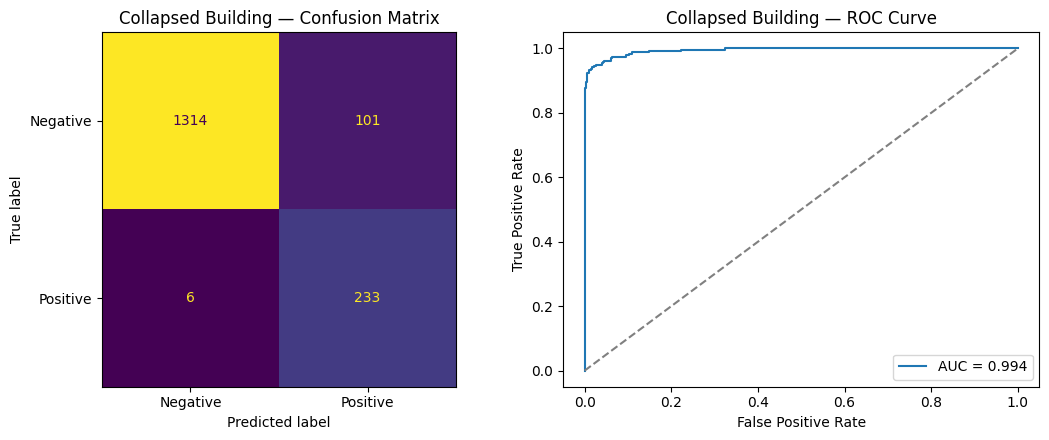

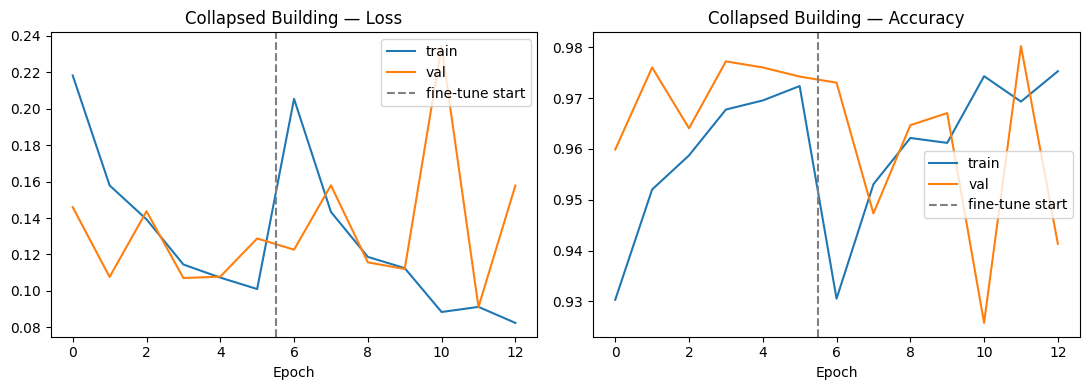

In [10]:
building_model, building_h1, building_h1_ft, building_results = train_binary_classifier(
    task_name="Collapsed Building",
    positive_class="Earthquake",
    save_path=os.path.join(OUT_DIR, "collapsed_building_classifier.keras"),
)

In [11]:
save_path = os.path.join(OUT_DIR, "collapsed_building_classifier.keras")

## Section F — Results Summary

In [12]:
summary_df = pd.DataFrame([
    {"model": "Collapsed Building (classifier)", **building_results},
])
print(summary_df.to_string(index=False))

save_path = os.path.join(OUT_DIR, "collapsed_building_classifier.h5")
if os.path.exists(save_path):
    size_mb = os.path.getsize(save_path) / (1024 * 1024)
    print(f"{save_path}  ({size_mb:.1f} MB)")
else:
    print(f"MISSING: {save_path}")


                          model  accuracy  precision   recall       f1  roc_auc
Collapsed Building (classifier)  0.935308   0.697605 0.974895 0.813264 0.993504
MISSING: /kaggle/working/collapsed_building_classifier.h5


## Section G — Sample Predictions (visual sanity check)

2026-09-20 18:21:31.057749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:21:31.215177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:21:31.347663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


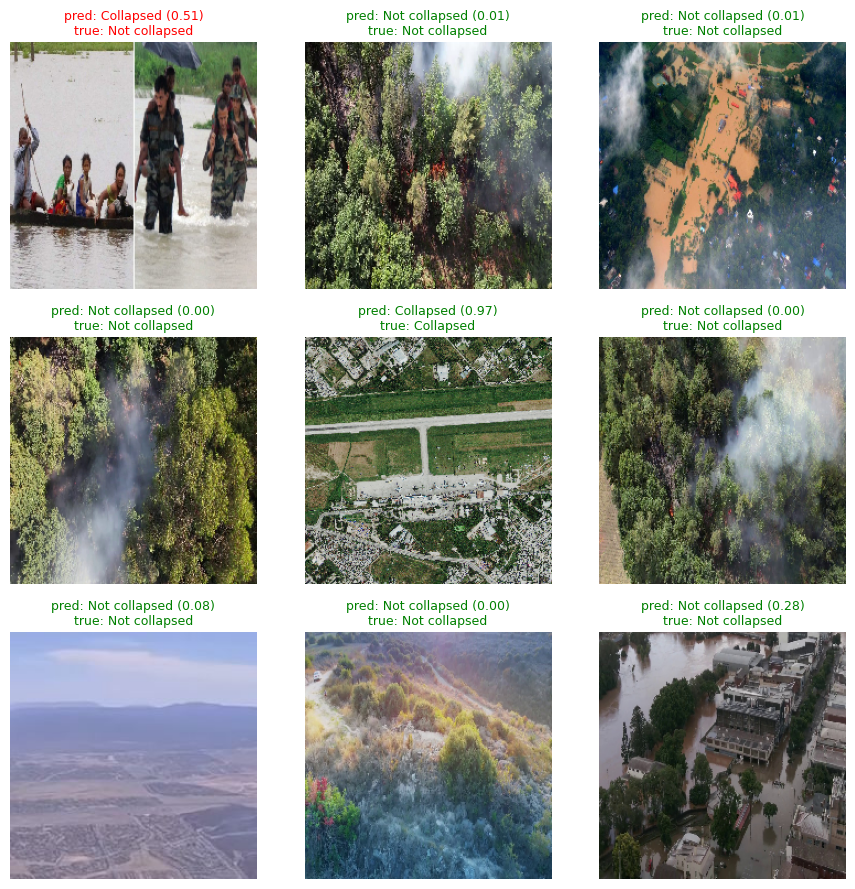

In [13]:
test_fp, test_y = build_aider_binary_filelist("Earthquake", aider_splits["test"])
sample_idx = random.sample(range(len(test_fp)), min(9, len(test_fp)))

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, idx in zip(axes.ravel(), sample_idx):
    img = load_and_preprocess_image(test_fp[idx], CLF_IMG_SIZE)
    prob = float(building_model.predict(img[None, ...], verbose=0)[0, 0])
    pred_label = "Collapsed" if prob >= 0.5 else "Not collapsed"
    true_label = "Collapsed" if test_y[idx] == 1 else "Not collapsed"
    correct = pred_label == true_label

    ax.imshow(img.numpy())
    ax.set_title(f"pred: {pred_label} ({prob:.2f})\ntrue: {true_label}",
                 color="green" if correct else "red", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


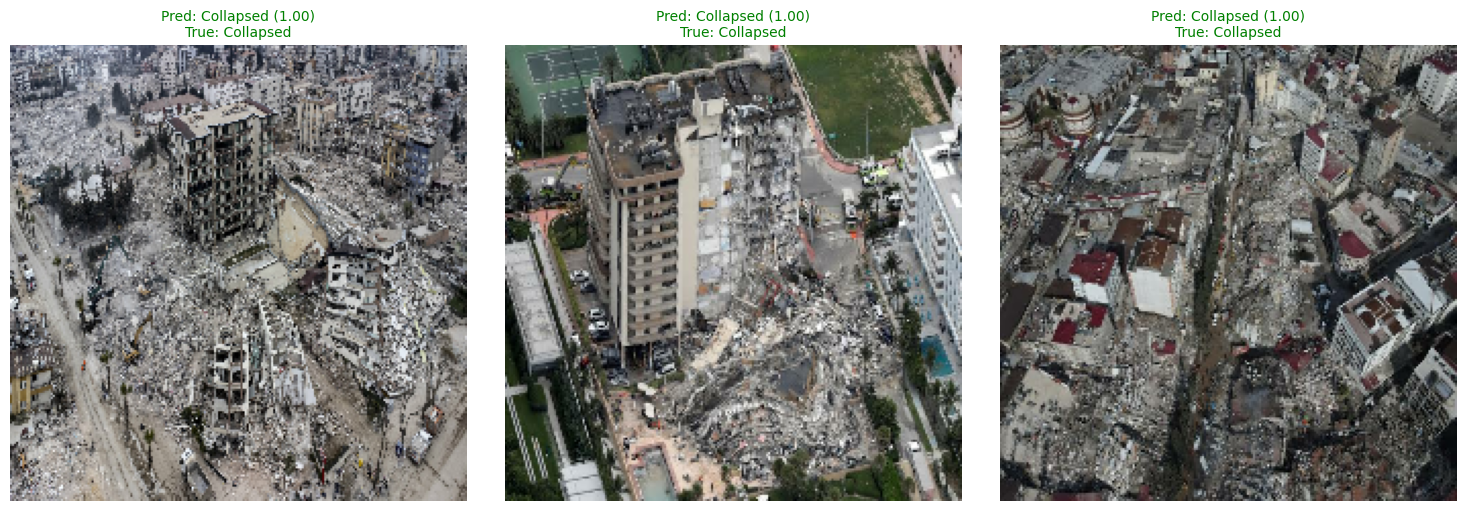

In [15]:
fig, axes = plt.subplots(1, len(custom_images), figsize=(15, 5))

if len(custom_images) == 1:
    axes = [axes]

for ax, item in zip(axes, custom_images):
    img = load_and_preprocess_image(item["path"], CLF_IMG_SIZE)

    prob = float(
        building_model.predict(img[None, ...], verbose=0)[0, 0]
    )

    pred_label = "Collapsed" if prob >= 0.5 else "Not collapsed"
    true_label = item["true_label"]
    correct = pred_label == true_label

    ax.imshow(img.numpy())
    ax.set_title(
        f"Pred: {pred_label} ({prob:.2f})\n"
        f"True: {true_label}",
        color="green" if correct else "red",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()